## Анализ финансовых транзакций и клиентов


### 1. Очистка и подготовка данных. Проверить данные на пропущенные и аномальные значения (например, отрицательные суммы транзакций). Удалить или исправить некорректные данные. Привести формат дат к единому стандарту.


In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
from sklearn.linear_model import LinearRegression


In [86]:
td  = pd.read_excel('../data/transactions_data.xlsx')
td.dropna(subset=['transaction_id'], inplace=True)

td = td[td['amount']>0].copy()

td['transaction_date'] = pd.to_datetime(td['transaction_date'], errors='coerce')

# данные буду фильтровать по задачам чтобы сохранять для каждого рассчета максимальное количество строк

print(len(td))
td.head()

9089


,transaction_id,client_id,transaction_date,service,amount,payment_method,city,consultant
0,ff36597c-df41-44a0-9f46-6aa1fe615270,1ec5ab91-fdd0-4925-a221-f0c4e04fe0e7,2025-01-04 00:02:20,Структурирование капитала,55838.059789,Банковский перевод,North Patrickport,Cheryl Waller
1,0d5263ec-413d-44d9-a9d3-a996e3a56b05,c940f45c-d29b-439a-8fa3-f75018cef528,2025-03-10 17:16:50,Структурирование капитала,37514.809209,Неизвестно,New Zacharyport,Frank Pollard
2,5e9a8978-df1c-483f-a53b-16149c93f11e,cfa21d7e-8499-43d0-9dfb-f4a1b94ce44c,2025-02-13 19:43:49,Структурирование капитала,21022.146872,Неизвестно,Port Michellemouth,Alexandra Meyer
3,524031ea-56e2-410a-aee2-e8fc6ae3fbc5,NaN,2025-03-02 03:14:10,Финансовое планирование,2313.980219,Неизвестно,Erichaven,Patricia Haas
4,421aaf04-c97d-42ac-b35f-09a56bbaf910,3f43d7bc-37f0-4535-8391-51702d6ff81e,2025-03-18 21:00:36,Структурирование капитала,5636.586955,Неизвестно,Bondstad,Melissa Pena


In [87]:
cd = pd.read_json('../data/clients_data.json')
cd.dropna(subset='id',inplace=True)
cd = cd[cd['net_worth']>=0].copy()
cd.reset_index(drop=True, inplace=True)
print(len(cd))
cd.head()

9323


,id,age,gender,net_worth
0,1ec5ab91-fdd0-4925-a221-f0c4e04fe0e7,41.0,Мужчина,2514729.46
1,c940f45c-d29b-439a-8fa3-f75018cef528,28.0,Мужчина,566568.29
2,cfa21d7e-8499-43d0-9dfb-f4a1b94ce44c,55.0,Женщина,1896001.28
3,3f43d7bc-37f0-4535-8391-51702d6ff81e,31.0,Мужчина,4865849.92
4,900f7d6b-ee7f-49e6-ae9f-e5ea9e04ab4c,59.0,Женщина,3992281.84


### 2. Анализ данных. Определить топ-5 наиболее популярных услуг по количеству заказов. Рассчитать среднюю сумму транзакций по каждому городу. Определить услугу с наибольшей выручкой (по сумме amount). Вычислить процент транзакций по способам оплаты (наличные, банковский перевод и т. д.). Рассчитать выручку за последний месяц (по сумме amount).


**Топ 5 популярных услуг:** 

In [88]:
td_with_correct_service = td[td['service']!="Неизвестная услуга"]
top_service_by_popularity = td_with_correct_service.groupby('service')['transaction_id'].count().sort_values(ascending=False)
top_service_by_popularity.rename('count', inplace=True)
top_service_by_popularity.head(5)

service
Инвестиционное консультирование    2215
Управление активами                1823
Налоговое планирование             1391
Финансовое планирование            1391
Структурирование капитала          1371
Name: count, dtype: int64

**Средняя сумма транзакций по каждому городу:**

In [89]:
td_with_correct_city = td[td["city"]!= "Неизвестный город"]
average_sum_by_city = td_with_correct_city.groupby('city')['amount'].mean().sort_values(ascending=False)
average_sum_by_city.rename('mean', inplace=True)
average_sum_by_city

city
Port Michellemouth    56208.902981
Michellehaven         55655.763082
New Tommyborough      55289.243790
East Rachelmouth      55149.591739
Harrisberg            53340.315622
North Lauriebury      53100.568989
Trevinoberg           52894.827859
North Melissaland     52800.683783
New Zacharyport       52598.507412
Kaneburgh             52488.018526
Johnsonfort           52126.081975
Bondstad              52071.688209
Lake Tina             52020.959261
West Meredithhaven    51723.692000
South Andrew          51628.956930
Krystalland           51383.984185
Lake Arielmouth       51352.542096
North Emily           50876.202298
Patelbury             50786.676205
Davidsonborough       50201.615899
Hamiltontown          50074.185613
Ronaldville           49695.500125
Aprilstad             49602.159009
Mayoberg              49465.834594
Erichaven             49408.469815
North Hannahmouth     49396.418768
New Chelseaberg       49213.133952
Port Jordan           48920.125212
Tonystad       

**Услуга с наибольшей выручкой (по сумме amount):**

In [90]:
top_services_by_revenue = td_with_correct_service.groupby('service')['amount'].sum().sort_values(ascending=False)
top_services_by_revenue.rename('revenue', inplace=True)
top_service_by_revenue = top_services_by_revenue.idxmax()
print(f"Услуга с наибольшей выручкой: {top_service_by_revenue}")


Услуга с наибольшей выручкой: Инвестиционное консультирование


In [91]:
print(f"Весь топ услуг по выручке:{top_services_by_revenue}")

Весь топ услуг по выручке:service
Инвестиционное консультирование    1.103218e+08
Управление активами                8.965264e+07
Финансовое планирование            6.940020e+07
Налоговое планирование             6.872679e+07
Структурирование капитала          6.597103e+07
Name: revenue, dtype: float64


**Вычисление процента транзакций по способам оплаты (наличные, банковский перевод и т. д.):**

In [92]:
td_with_correct_payment_method = td[td["payment_method"]!='Неизвестно']
payment_method_percentages = td_with_correct_payment_method['payment_method'].value_counts(normalize=True)*100
payment_method_percentages

payment_method
Кредитная карта       44.471624
Банковский перевод    38.527397
Наличные              10.983366
Криптовалюта           6.017613
Name: proportion, dtype: float64

**Рассчет выручки за последний месяц (по сумме amount):**

In [93]:
last_transaction_date = td['transaction_date'].max()
td_with_last_month = td[(td['transaction_date'].dt.year==last_transaction_date.year) & (td['transaction_date'].dt.month==last_transaction_date.month)] 
revenue_with_last_month = td_with_last_month['amount'].sum()
print(f"Выручка за последний месяц: {revenue_with_last_month}")

Выручка за последний месяц: 100364172.61385366


### 3. Объединение данных. Объединить транзакции с клиентскими данными (по id). Создать новую колонку с уровнями активов. Провести анализ по уровням активов и определить, какие категории клиентов приносят наибольшую выручку. Категории клиентов по уровню активов:            
Низкий капитал (<100 000)  
Средний капитал (100 000 - 1 000 000)  
Высокий капитал (>1 000 000)


In [94]:
cd.rename(columns={'id':'client_id'}, inplace=True)
df = pd.merge(td, cd, on='client_id', how='left')
df.head(3)

,transaction_id,client_id,transaction_date,service,amount,payment_method,city,consultant,age,gender,net_worth
0,ff36597c-df41-44a0-9f46-6aa1fe615270,1ec5ab91-fdd0-4925-a221-f0c4e04fe0e7,2025-01-04 00:02:20,Структурирование капитала,55838.059789,Банковский перевод,North Patrickport,Cheryl Waller,41.0,Мужчина,2514729.46
1,0d5263ec-413d-44d9-a9d3-a996e3a56b05,c940f45c-d29b-439a-8fa3-f75018cef528,2025-03-10 17:16:50,Структурирование капитала,37514.809209,Неизвестно,New Zacharyport,Frank Pollard,28.0,Мужчина,566568.29
2,5e9a8978-df1c-483f-a53b-16149c93f11e,cfa21d7e-8499-43d0-9dfb-f4a1b94ce44c,2025-02-13 19:43:49,Структурирование капитала,21022.146872,Неизвестно,Port Michellemouth,Alexandra Meyer,55.0,Женщина,1896001.28


In [95]:
conditions = [
    df['net_worth']<100000,
    (df['net_worth']>=100000) & (df['net_worth']<1000000),
    df['net_worth']>=1000000
]
levels = ['Низкий капитал', 'Средний капитал', 'Высокий капитал']
df['net_worth_level'] = np.select(conditions, levels, default='Неизвестно')
df.head(3)

,transaction_id,client_id,transaction_date,service,amount,payment_method,city,consultant,age,gender,net_worth,net_worth_level
0,ff36597c-df41-44a0-9f46-6aa1fe615270,1ec5ab91-fdd0-4925-a221-f0c4e04fe0e7,2025-01-04 00:02:20,Структурирование капитала,55838.059789,Банковский перевод,North Patrickport,Cheryl Waller,41.0,Мужчина,2514729.46,Высокий капитал
1,0d5263ec-413d-44d9-a9d3-a996e3a56b05,c940f45c-d29b-439a-8fa3-f75018cef528,2025-03-10 17:16:50,Структурирование капитала,37514.809209,Неизвестно,New Zacharyport,Frank Pollard,28.0,Мужчина,566568.29,Средний капитал
2,5e9a8978-df1c-483f-a53b-16149c93f11e,cfa21d7e-8499-43d0-9dfb-f4a1b94ce44c,2025-02-13 19:43:49,Структурирование капитала,21022.146872,Неизвестно,Port Michellemouth,Alexandra Meyer,55.0,Женщина,1896001.28,Высокий капитал


In [96]:
revenue_by_net_worth_level = df[df['net_worth_level']!= "Неизвестно"].groupby('net_worth_level')['amount'].sum().sort_values(ascending=False)
print(f'Наибольшую выручку приносят люди из категории: {revenue_by_net_worth_level.idxmax()}')

Наибольшую выручку приносят люди из категории: Высокий капитал


### 4. Визуализация данных (* дополнительное задание). Построить распределение сумм транзакций. Создать диаграмму выручки по услугам. Построить график зависимости средней суммы транзакции от возраста клиентов.


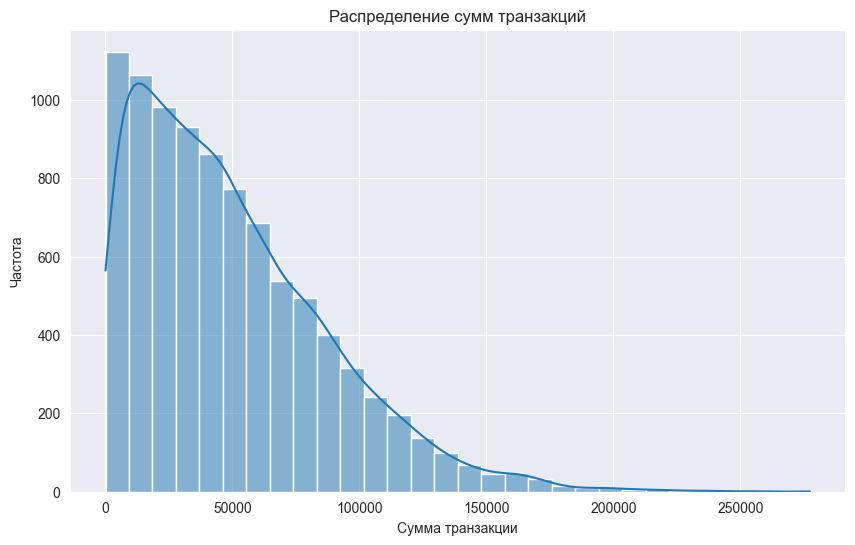

In [97]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df, x='amount', bins=30, kde=True)

plt.title('Распределение сумм транзакций')
plt.xlabel('Сумма транзакции')
plt.ylabel('Частота')
plt.show()

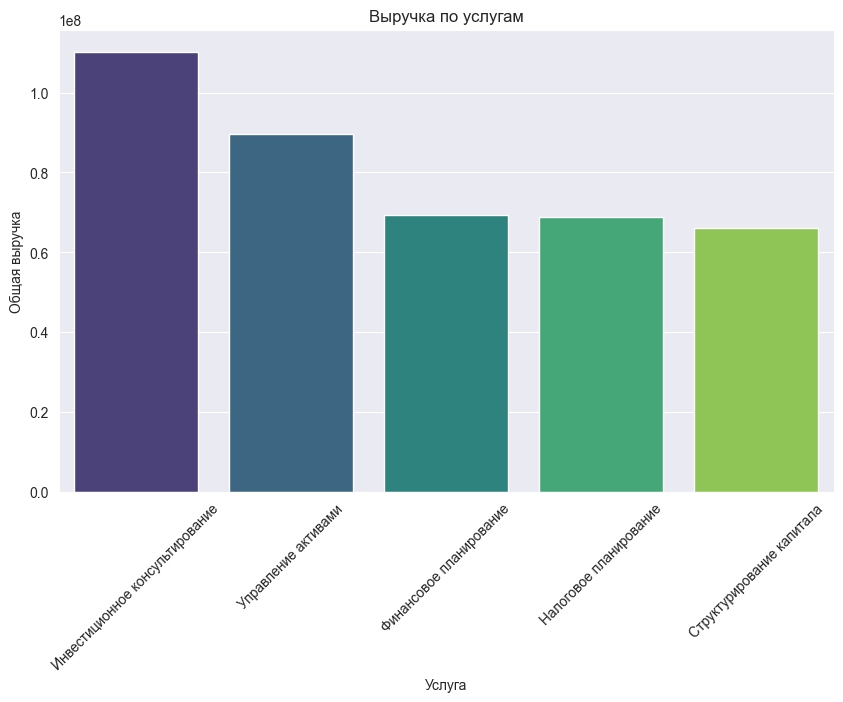

In [98]:

plt.figure(figsize=(10, 6))

sns.barplot(x=top_services_by_revenue.index, y=top_services_by_revenue.values, hue=top_services_by_revenue.index, palette='viridis')

plt.title('Выручка по услугам')
plt.xlabel('Услуга')
plt.ylabel('Общая выручка')
plt.xticks(rotation=45) 
plt.show()

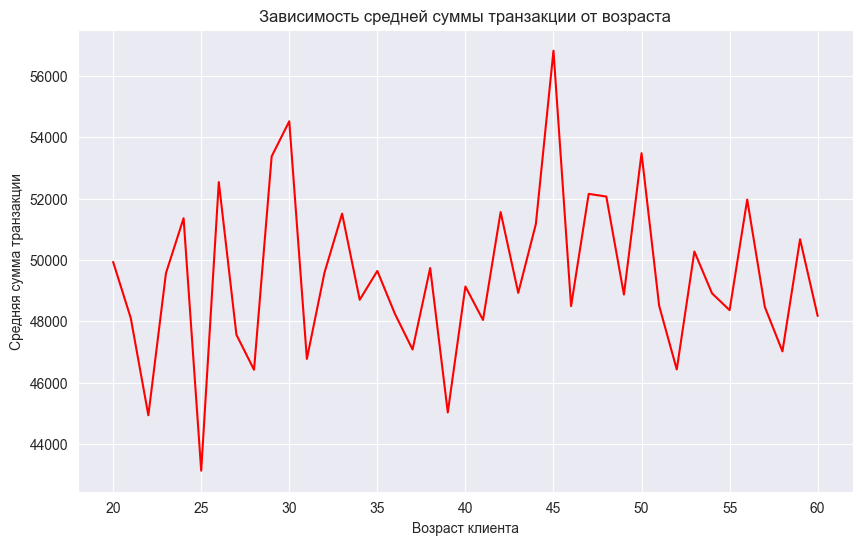

In [99]:
avg_amount_by_age = df.groupby('age')['amount'].mean().reset_index()

plt.figure(figsize=(10, 6))

sns.lineplot(data=avg_amount_by_age, x='age', y='amount', color='red')

plt.title('Зависимость средней суммы транзакции от возраста')
plt.xlabel('Возраст клиента')
plt.ylabel('Средняя сумма транзакции')
plt.grid(True) 
plt.show()

### 5. Прогнозирование (* дополнительное задание). Прогнозирование спроса на следующий месяц (например, с использованием линейной регрессии).

In [100]:
df = df[df['service']!="Неизвестная услуга"]
df['month_year'] = df['transaction_date'].dt.to_period('M')
monthly_revenue = df.groupby(['month_year','service'])['transaction_id'].size().reset_index()
monthly_revenue.rename(columns={'month_year':'month_year', 'service':'service', 'transaction_id': 'count'}, inplace=True)

# тк сейчас мы работаем в рамках одного года, достаточно разбить просто по номеру самого месяца. Если бы было несколько лет 
# то подготовка данных была бы реализована чуть по другому чтобы отделять месяца разных годов
monthly_revenue['month'] = monthly_revenue['month_year'].dt.month

monthly_revenue_encoded = pd.get_dummies(monthly_revenue, columns=['service'], drop_first=False)

monthly_revenue_encoded.head()

,month_year,count,month,service_Инвестиционное консультирование,service_Налоговое планирование,service_Структурирование капитала,service_Управление активами,service_Финансовое планирование
0,2025-01,763,1,True,False,False,False,False
1,2025-01,513,1,False,True,False,False,False
2,2025-01,483,1,False,False,True,False,False
3,2025-01,659,1,False,False,False,True,False
4,2025-01,495,1,False,False,False,False,True


In [101]:
new_month_data = {
    'month_year': (df['month_year'].max()+1),
    'service': df['service'].unique()
}
X_cols = ['month'] + [col for col in monthly_revenue_encoded.columns if "service_" in col]

future_month = pd.DataFrame(new_month_data)
future_month = future_month[future_month['service']!="Неизвестная услуга"]
future_month['month'] = future_month['month_year'].dt.month
future_month_encoded = pd.get_dummies(future_month, columns=['service'], drop_first=False)
future_month_encoded = future_month_encoded.reindex(columns=X_cols, fill_value=0) # гарантирует сто столбцы в таком же порядке

future_month_encoded

,month,service_Инвестиционное консультирование,service_Налоговое планирование,service_Структурирование капитала,service_Управление активами,service_Финансовое планирование
0,4,False,False,True,False,False
1,4,False,False,False,False,True
2,4,True,False,False,False,False
3,4,False,True,False,False,False
4,4,False,False,False,True,False


In [102]:
model = LinearRegression()
X = monthly_revenue_encoded[X_cols]
y = monthly_revenue_encoded['count']
model.fit(X, y)
future_count = model.predict(future_month_encoded[X_cols])
future_month['count'] = future_count
future_month.sort_values(by='count', ascending=False, inplace=True)
future_month.drop(columns='month', inplace=True)
print(f"Прогнозы на следующий месяц: {future_month}")


Прогнозы на следующий месяц:   month_year                          service       count
2    2025-04  Инвестиционное консультирование  440.666667
4    2025-04              Управление активами  324.666667
1    2025-04          Финансовое планирование  198.666667
3    2025-04           Налоговое планирование  195.666667
0    2025-04        Структурирование капитала  186.333333
